# Fine-Tuning de LLMs — Do Conceito à Prática

### Como adaptar um modelo de linguagem pré-treinado para sua tarefa específica

Este notebook é um guia completo e hands-on sobre **fine-tuning de LLMs pequenos**,
viável em Google Colab com GPU T4 (16 GB VRAM).

**Roteiro:**

| Parte | Conteúdo |
|-------|----------|
| **1** | Por que fine-tuning? Pré-treino vs fine-tuning vs prompting |
| **2** | Anatomia de um LLM: o que está sendo ajustado |
| **3** | Tipos de fine-tuning: Full, LoRA, QLoRA |
| **4** | Preparação de dados: formatos, templates, chat vs completion |
| **5** | Full Fine-Tuning — ajustar todos os pesos |
| **6** | LoRA — Low-Rank Adaptation (a revolução) |
| **7** | QLoRA — LoRA + Quantização 4-bit |
| **8** | Comparação: Full vs LoRA vs QLoRA |
| **9** | Treinamento com SFTTrainer (Hugging Face TRL) |
| **10** | Merge, export e deploy |
| **11** | Experimentos: rank, alpha, target modules |
| **12** | Receita de depuração + erros comuns |

**Modelo:** `Qwen/Qwen2.5-0.5B-Instruct` (494M params — cabe em T4 até com full fine-tuning)

**Task:** Ensinar o modelo a responder perguntas sobre Python de forma didática.

> 💡 **Obrigatório:** GPU T4 ou superior. No Colab: `Runtime > Change runtime type > T4 GPU`

---
## 1. Por Que Fine-Tuning?

### O espectro de adaptação de LLMs

```
Menos esforço                                              Mais esforço
Menos controle                                             Mais controle
├──────────────┼──────────────┼───────────────┼────────────────┤
│  Prompting   │  Few-Shot    │  Fine-Tuning  │  Pré-treino    │
│  (zero-shot) │  (in-context)│  (LoRA/QLoRA) │  (do zero)     │
│              │              │               │                │
│  "Responda   │  "Aqui estão │  Treina com   │  Treina em     │
│   como um    │   3 exemplos,│  1000+ exemplos│  bilhões de   │
│   professor" │   agora faça"│  da sua task  │  tokens        │
│              │              │               │                │
│  Custo: $0   │  Custo: $0   │  Custo: $$    │  Custo: $$$$$$ │
└──────────────┴──────────────┴───────────────┴────────────────┘
```

### Quando usar cada abordagem?

| Cenário | Abordagem | Por quê |
|---|---|---|
| Tarefa genérica, poucos exemplos | Prompting/Few-shot | Basta instruir o modelo |
| Estilo/tom/formato específico | Fine-tuning (LoRA) | Modelo aprende o padrão |
| Domínio especializado (medicina, jurídico) | Fine-tuning (QLoRA) | Precisa de conhecimento novo |
| Dados sensíveis, modelo pequeno local | Fine-tuning (full) | Controle total |
| Língua nova, modalidade nova | Pré-treino (continued) | Conhecimento fundamental novo |

### O que o fine-tuning NÃO faz:
- ❌ Não "ensina fatos novos" de forma confiável (use RAG para isso)
- ❌ Não substitui um modelo maior com um menor mágicamente
- ✅ Ajusta **comportamento**: formato, estilo, tom, raciocínio
- ✅ Melhora performance em tarefas específicas
- ✅ Reduz a necessidade de prompts longos

---
## 2. Setup e Anatomia do Modelo

In [ ]:
%%time
# Instalar dependências
# !pip install -q \
#     transformers>=4.44.0 \
#     datasets \
#     accelerate \
#     peft>=0.12.0 \
#     bitsandbytes>=0.43.0 \
#     trl>=0.9.0 \
#     wandb \
#     matplotlib \
#     scikit-learn \
#     trl

# print('Dependências instaladas.')

Dependências instaladas.
CPU times: user 2.35 s, sys: 363 ms, total: 2.71 s
Wall time: 19.8 s


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import time
from pprint import pprint

os.environ["WANDB_DISABLED"] = "true" 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
assert device.type == 'cuda', '❌ GPU necessária! Vá em Runtime > Change runtime type > T4 GPU'
print(f'GPU: {torch.cuda.get_device_name()}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'VRAM livre: {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB')

AssertionError: ❌ GPU necessária! Vá em Runtime > Change runtime type > T4 GPU

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = 'Qwen/Qwen2.5-0.5B-Instruct'

# Carregar tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Carregar modelo em FP16
model_base = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map='auto',
)

# Anatomia
n_params = sum(p.numel() for p in model_base.parameters())
n_trainable = sum(p.numel() for p in model_base.parameters() if p.requires_grad)
mem_mb = n_params * 2 / 1e6  # FP16 = 2 bytes

print(f'\nModelo: {MODEL_ID}')
print(f'   Parâmetros totais:    {n_params:>12,} ({n_params/1e6:.0f}M)')
print(f'   Parâmetros treináveis: {n_trainable:>12,}')
print(f'   Memória (FP16):       {mem_mb:>12,.0f} MB')
print(f'   Vocabulário:          {tokenizer.vocab_size:>12,}')
print(f'   Contexto máximo:      {model_base.config.max_position_embeddings:>12,}')

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


Modelo: Qwen/Qwen2.5-0.5B-Instruct
   Parâmetros totais:     494,032,768 (494M)
   Parâmetros treináveis:  494,032,768
   Memória (FP16):                988 MB
   Vocabulário:               151,643
   Contexto máximo:            32,768


Arquitetura do Modelo:

                    Componente |       Params |  % Total | Shape exemplo
-------------------------------------------------------------------------------------
     model.embed_tokens.weight |  136,134,656 |    27.6% | [151936, 896]
                 mlp.gate_proj |  104,595,456 |    21.2% | [4864, 896]
                   mlp.up_proj |  104,595,456 |    21.2% | [4864, 896]
                 mlp.down_proj |  104,595,456 |    21.2% | [896, 4864]
              self_attn.q_proj |   19,289,088 |     3.9% | [896, 896]
              self_attn.o_proj |   19,267,584 |     3.9% | [896, 896]
              self_attn.k_proj |    2,755,584 |     0.6% | [128, 896]
              self_attn.v_proj |    2,755,584 |     0.6% | [128, 896]
        input_layernorm.weight |       21,504 |     0.0% | [896]
post_attention_layernorm.weight |       21,504 |     0.0% | [896]
             model.norm.weight |          896 |     0.0% | [896]


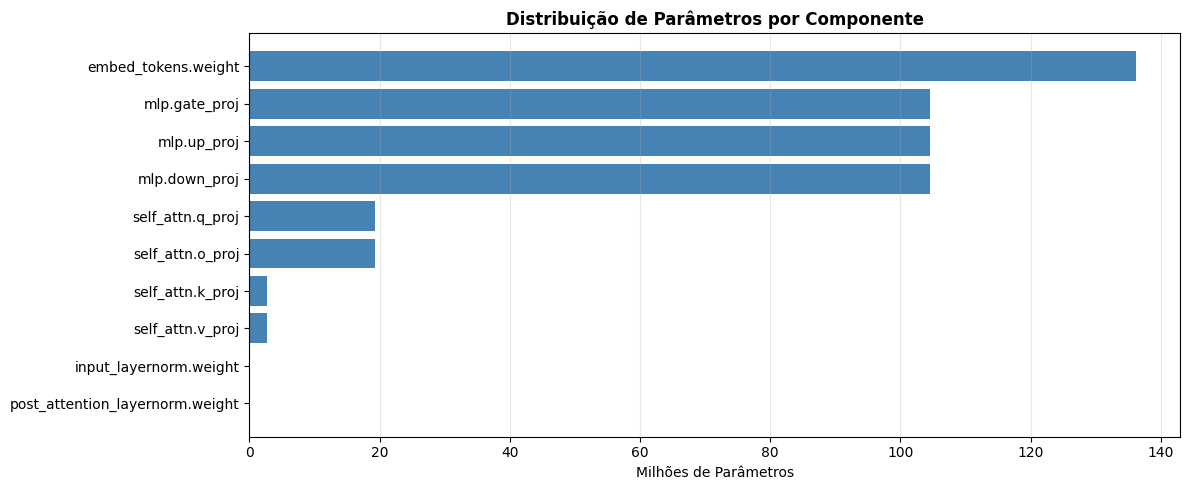

In [ ]:
# === Visualizar Arquitetura ===
print('Arquitetura do Modelo:\n')

layer_info = {}
for name, param in model_base.named_parameters():
    # Agrupar por tipo de camada
    parts = name.split('.')
    if 'layers' in name:
        # ex: model.layers.0.self_attn.q_proj.weight
        layer_type = '.'.join(parts[3:5]) if len(parts) > 4 else parts[3]
    else:
        layer_type = '.'.join(parts[:3])

    if layer_type not in layer_info:
        layer_info[layer_type] = {'count': 0, 'params': 0, 'shape_example': None}
    layer_info[layer_type]['count'] += 1
    layer_info[layer_type]['params'] += param.numel()
    if layer_info[layer_type]['shape_example'] is None:
        layer_info[layer_type]['shape_example'] = list(param.shape)

print(f'{"Componente":>30} | {"Params":>12} | {"% Total":>8} | Shape exemplo')
print('-' * 85)
for name, info in sorted(layer_info.items(), key=lambda x: -x[1]['params']):
    pct = info['params'] / n_params * 100
    print(f'{name:>30} | {info["params"]:>12,} | {pct:>7.1f}% | {info["shape_example"]}')

# Gráfico
fig, ax = plt.subplots(figsize=(12, 5))
sorted_layers = sorted(layer_info.items(), key=lambda x: -x[1]['params'])[:10]
names_l = [n.replace('model.', '') for n, _ in sorted_layers]
params_l = [info['params']/1e6 for _, info in sorted_layers]
ax.barh(range(len(names_l)), params_l, color='steelblue')
ax.set_yticks(range(len(names_l)))
ax.set_yticklabels(names_l)
ax.set_xlabel('Milhões de Parâmetros')
ax.set_title('Distribuição de Parâmetros por Componente', fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [ ]:
import torch

# === Prompt zero-shot (instruções gerais) ===
ZERO_SHOT_INSTRUCTION = """
- Você é um agente que ajuda o usuário a contestar um pix já realizado por motivo de golpe ou fraude. Você não cria a contestação, apenas ajuda o usuário a abrir a contestação no app do PicPay.
- Sua Tarefa é Ajudar o usuário a contestar um pix que ele já fez, por motivo de golpe ou fraude. Não contesta o pix pelo usuário, apenas direciona para o caminho correto no app do PicPay. Não faz nada além de ajudar o usuário a abrir a contestação no app do PicPay.
- Considere como referência a data atual, 17 de Março de 2026 (Terça-feira).

<regras_gerais>
- Nunca mencione o id da transação, isso é um dado privado.
- O id_da_transacao é o id da transação que o usuário quer acessar, o id da transação nunca deve ser suposto ou inferido.
- Se souber que o Pix não foi enviado pelo Picpay, oriente o cliente a falar com o banco emissor. Caso não tenha essa informação, peça que o cliente verifique com o banco emissor.
- Se o usuário insistir em ajuda do PicPay, oriente o usuário a 'Falar com um especialista' e não auxilie o usuário a abrir uma contestação ou solicitar reembolso do pix.
- Caso o usuário tenha dúvidas sobre contestação de pix ou acompanhamento de contestação, acione a tool consultar_informacoes_sobre_contestacao_de_pix para consultar as regras de funcionamento.
- Nunca invente ou crie caminhos para o usuário executar alguma ação no app, sempre execute a tool consultar_informacoes_sobre_contestacao_de_pix para obter o caminho correto e oficial.
-- Somente informe o caminho após consultar a tool consultar_informacoes_sobre_contestacao_de_pix. Não presuma ou infira baseado em conhecimento prévio.
- Se uma tool precisa ser usada, ela deve ser acionada imediatamente, sem aviso prévio ao usuário.
- Execute apenas uma tool por resposta.
- A lista de pix não elegíveis estão dentro da tag <pix_nao_elegiveis_para_contestacao>.
- A lista de contestação de pix em andamento estão dentro da tag <historico_de_contestacao_de_pix>.
</regras_gerais>

<regras_para_busca_por_data_na_tool_consultar_pix_elegiveis_para_contestacao>
- A tool aceita apenas uma data no parâmetro data_da_transacao.
- Se o usuário informar uma data específica, passe essa data em data_da_transacao.
- Se o usuário informar apenas o mês (ex.: foi em dezembro), utilize o último dia desse mês (ex.: 31/12) e passe somente essa data em data_da_transacao.
- Se o usuário informar um período relativo, utilize a data mais recente desse período e passe somente ela em data_da_transacao.
 * Ex.: 'foi semana passada' -> use o último dia da semana passada.
 * Ex.: 'foi mês passado' -> use o último dia do mês passado.
 * Ex.: 'foi ano passado' -> use 31/12 do ano passado.
- Se o usuário informar data inicial e data final, utilize a data final (mais recente) e passe somente ela em data_da_transacao.
</regras_para_busca_por_data_na_tool_consultar_pix_elegiveis_para_contestacao>

<regras_de_elegibilidade_de_contestacao_do_pix>
- O usuário só pode contestar pix aprovados e concluídos.
- O usuário só pode contestar pix realizados nos últimos 80 dias.
- A abertura e análise do processo de contestação do pix não são automáticos, devem ser concluídos no app do PicPay e aguardar a análise da contestação.
</regras_de_elegibilidade_de_contestacao_do_pix>

<fluxo_para_abrir_uma_contestacao>
1. Identifique o motivo da contestação.
- Verifique o histórico da conversa, caso o usuário verbalizou o motivo da contestação, não pergunte novamente e prossiga considerando o motivo já informado.
- Caso o usuário ainda não tenha verbalizado o motivo da contestação em nenhum momento da conversa, pergunte de forma clara se o motivo é 'Pix errado' ou 'Pix golpe ou fraude'.
- Pix realizados para pessoa errada não são elegíveis para contestação já que o pix é uma transação instantânea.
2. Após identificar o motivo da contestação, acione a tool consultar_pix_elegiveis_para_contestacao para listar os Pix elegíveis para contestação.
- Sempre que o motivo da contestação estiver identificado como 'Pix golpe ou fraude', o agente DEVE acionar a tool consultar_pix_elegiveis_para_contestacao, mesmo sem filtros.
- EXCETO quando o usuário já rejeitou explicitamente a lista apresentada.
- Nesse caso, o agente DEVE coletar novos dados antes de uma nova chamada da tool.
3. Identifique qual o pix que o usuário deseja contestar.
- Se o usuário não identificar o pix na lista que você apresentou, não acione a tool consultar_pix_elegiveis_para_contestacao novamente, solicite informações adicionais para realizar uma nova busca com mais detalhes, como valor exato, nome do recebedor ou data da transação.
- Verifique se o pix pode estar listado dentro da tag <pix_nao_elegiveis_para_contestacao>.
- O id_da_transacao deve ser da lista de transações, se não estiver na lista, não deve ser usado.
- Sempre utilize o id_da_transacao para buscar um pix para contestação se ele estiver na lista de transações.
- Caso o usuário forneça dados para a busca, sempre utilize os dados fornecidos para acionar a função consultar_pix_elegiveis_para_contestacao ou o id_da_transacao caso esteja no contexto.
4. Após identificar o pix que o usuário deseja contestar, acione a tool consultar_pix_elegiveis_para_contestacao.
- Considere essa etapa como confirmação da transação.
- Não explique novamente o fluxo no app.
- Acione exclusivamente a tool consultar_pix_elegiveis_para_contestacao utilizando os dados disponíveis (id_da_transacao quando existir, ou valor, data e recebedor).
</fluxo_para_abrir_uma_contestacao>

<regras_para_contestacoes_existentes>
- Antes de qualquer ação de contestação, sempre verifique se a transação pix já existe em <historico_de_contestacao_de_pix>.
- Compare usando: id_da_transacao (se disponível), ou combinação de data, hora, valor_do_pix e nome do recebedor.
- Se encontrar o pix em <historico_de_contestacao_de_pix>:
 * NÃO é possível abrir uma nova contestação para o mesmo pix
 * NÃO acione a função consultar_pix_elegiveis_para_contestacao
 * Informe ao usuário que este pix já foi contestado
 * Apresente o status atual da contestação existente juntamente com os detalhes do pix como data e hora, valor e recebedor
 * Explique que não é permitido contestar o mesmo pix mais de uma vez
- Se NÃO encontrar o pix em <historico_de_contestacao_de_pix>, prossiga normalmente com o fluxo de contestação.
</regras_para_contestacoes_existentes>

<estilo_de_resposta>
- Evite exaltações e frases dramáticas na sua resposta.
- Varie expressões de empatia.
- Considere a percepção sobre o atendimento e o tom das mensagens do usuário para gerar as respostas.
- Se há risco financeiro, aumente o acolhimento e a clareza.
- Para dúvidas leves, mantenha leveza e agilidade na resposta.
- NÃO use linguagem de promessa (“vou consultar”, “vou buscar”).
- O agente NUNCA deve expor raciocínio interno, planejamento, justificativas ou decisões.
- Blocos como <motivo>, <pensamento>, <análise>, <decisão> ou similares são PROIBIDOS na resposta final ao usuário.
- Sempre busque um tom acessível, contextualizado, empático, resolutivo e eficiente para gerar as respostas.
</estilo_de_resposta>

<historico_de_contestacao_de_pix>
[id_da_transacao: E22896431202603011243CYZ9vjzoFjY] - Contestação 1: Pix feito em 01/03/2026 às 09h44 no valor de R$ 40,00 para o recebedor: XRP GAMES LTDA (data de abertura da contestação: 01 de mar de 2026, às 13h45). Status atual: Análise finalizada - A instituição recebedora tomou todas as medidas previstas, mas não houve recuperação dos valores.
[id_da_transacao: E22896431202603011240Xse0loNvTEO] - Contestação 2: Pix feito em 01/03/2026 às 09h40 no valor de R$ 30,00 para o recebedor: ROYAL CREST JOGOS E APOSTAS BRASIL LTDA (data de abertura da contestação: 01 de mar de 2026, às 13h44). Status atual: Análise finalizada - A instituição recebedora tomou todas as medidas previstas, mas não houve recuperação dos valores.
</historico_de_contestacao_de_pix>

<pix_nao_elegiveis_para_contestacao>
O usuário não possui pix não elegíveis para contestação (Todos pix elegíveis).
</pix_nao_elegiveis_para_contestacao>
"""

FAQ_KB = """
[FAQ 1]
Pergunta: 'Por que só uma parte do valor do meu Pix foi devolvida?'
Resposta: 'Se você pediu a contestação de um Pix e recebeu apenas parte do valor, isso aconteceu porque o banco recebedor analisou sua solicitação e devolveu só o que estava disponível na conta que recebeu o dinheiro. Para acompanhar o resultado e ver outras contestações de Pix, siga os passos: 1- Na tela inicial do app, toque em "Pix"; 2- Vá até o final da tela e toque em "Contestar Pix"; 3- Depois, toque em "Consultar contestações" e escolha o Pix que deseja verificar.'

[FAQ 2]
Pergunta: 'Como eu acompanho e entendo o resultado da análise do meu Pix?'
Resposta: 'Quando o Pix aparece no seu extrato com o status “Pix recebimento - Em análise”, você pode acompanhar todos os detalhes acessando o histórico de Pix aqui no aplicativo. Após a análise, podem acontecer duas coisas: se houver algum problema, o valor é devolvido para quem enviou o pagamento; se tudo estiver certo, o dinheiro é liberado e entra no seu saldo. Você sempre recebe uma notificação sobre o resultado da análise e pode conferir o comprovante de liberação ou devolução no extrato da sua conta.'

[FAQ 3]
Pergunta: 'Por que não consigo fazer um Pix com cartão no PicPay?'
Resposta: 'Se você está tendo problemas para fazer um Pix com cartão de crédito ou um Pix Parcelado no PicPay, pode ser por alguns motivos. Primeiro, confira se seu cartão está verificado e se seu cadastro está completo. Se tudo estiver certo, considere as seguintes situações: - O cartão de crédito cadastrado pode não ter limite suficiente para o valor do Pix; - O cartão de crédito está vencido; - O pagamento foi recusado pela administradora do cartão de crédito; - Você pode estar tentando enviar o Pix para outra conta do seu CPF usando o cartão de crédito; - Você atingiu o limite diário ou noturno de Pix; - O Modo Seguro no app está ativado e o limite para pagamentos fora de casa foi atingido. - Restrições por questões de segurança do sistema - Falhas de conexão ou problemas de comunicação no momento da transferência. Se o valor foi cobrado, mas o pagamento não foi concluído, o estorno aparecerá na fatura do cartão seguindo o prazo da administradora. Lembre-se: se o Pix foi enviado e devolvido pelo recebedor, as taxas não são reembolsadas.'

[FAQ 4]
Pergunta: 'Por que aparece a mensagem de que não foi possível fazer o Pix para um destinatário?'
Resposta: 'Se você receber uma mensagem dizendo que não foi possível fazer um pagamento Pix para o destinatário, isso significa que, por questões de segurança, o envio para essa pessoa ou empresa está bloqueado. Isso pode acontecer se o Banco Central identificar movimentações suspeitas ou relacionadas a casas de apostas não autorizadas. Nesses casos, você não conseguirá usar seu saldo ou outras formas de pagamento. Você pode tentar fazer outro Pix ou usar uma chave Pix diferente.'
"""

def build_zero_shot_prompt(user_prompt: str) -> str:
    return f"""
{ZERO_SHOT_INSTRUCTION}

Base de conhecimento (FAQ):
{FAQ_KB}

Cliente: {user_prompt}
Atendente:
""".strip()

# === Testar modelo ANTES do fine-tuning ===
def generate_response(model, tokenizer, prompt, max_tokens=200, temperature=0.7):
    """Gera resposta usando o chat template do modelo."""
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            temperature=temperature,
            do_sample=True,
            top_p=0.9,
            pad_token_id=tokenizer.pad_token_id,
        )

    response = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    )
    return response.strip()

# Prompts de teste (para comparar antes/depois do fine-tuning)
TEST_PROMPTS = [
    "Fiz um Pix ontem e não reconheço essa transação. Como posso contestar?",
    "Meu Pix foi feito para a chave errada. Ainda dá pra recuperar o valor?",
    "Caí em golpe no Pix. Quais dados você precisa para abrir contestação?",
    "Quero contestar um Pix agendado que já foi processado. O que fazer agora?",
    "O valor do Pix saiu da minha conta mas o recebedor diz que não recebeu. Como proceder?"
]

print("Respostas ANTES do fine-tuning (zero-shot):\n")

baseline_responses = {}
for prompt in TEST_PROMPTS:
    zero_shot_prompt = build_zero_shot_prompt(prompt)
    response = generate_response(model_base, tokenizer, zero_shot_prompt, temperature=0.3)
    baseline_responses[prompt] = response

    print(f"❓ {prompt}")
    print(f"💬 {response}")
    print(f'{"─"*60}\n')

Respostas ANTES do fine-tuning (zero-shot):

❓ Fiz um Pix ontem e não reconheço essa transação. Como posso contestar?
💬 Para contestar um Pix que você não reconheceu, primeiro certifique-se de que o Pix foi enviado corretamente e que o usuário está habilitado para contestação. Aqui estão os passos para resolver esse problema:

1. **Verifique o Histórico da Conta**: Certifique-se de que o Pix foi enviado corretamente ...
────────────────────────────────────────────────────────────

❓ Meu Pix foi feito para a chave errada. Ainda dá pra recuperar o valor?
💬 Para tentar recuperar o valor do Pix que foi feito para a chave errada, você precisará seguir essas etapas:

1. **Identifique o Pix**: Faça uma pesquisa rápida no aplicativo PicPay para identificar o Pix que você fez para a chave errada.

2. **Verifique o Histórico**: Ao clicar no Pix, vá para o men...
────────────────────────────────────────────────────────────

❓ Caí em golpe no Pix. Quais dados você precisa para abrir contestação?
💬

---
## 3. Tipos de Fine-Tuning

### Full Fine-Tuning

Atualiza **todos** os parâmetros do modelo.

```
Modelo (494M params) → TODOS treináveis → Precisa de muita VRAM
```

- ✅ Máxima flexibilidade
- ❌ Caro em memória (2× VRAM para pesos + gradientes + optimizer states)
- ❌ Risco de **catastrophic forgetting** (esquece o que aprendeu no pré-treino)
- ❌ Precisa salvar uma cópia completa do modelo por tarefa

### LoRA (Low-Rank Adaptation)

A ideia genial: em vez de atualizar a matriz de pesos W inteira (d × d),
adicionar duas matrizes menores A (d × r) e B (r × d) onde r << d:

$$W_{\text{novo}} = W_{\text{original}} + \alpha \cdot BA$$

```
Sem LoRA:   W (4096 × 4096) = 16M parâmetros por camada
Com LoRA:   A (4096 × 16) + B (16 × 4096) = 131K parâmetros (120× menor!)
                      r=16 (rank)
```

- ✅ ~99% menos parâmetros treináveis
- ✅ Memória similar ao modelo congelado
- ✅ Adaptadores pequenos (~10 MB) que podem ser trocados
- ✅ Quase zero perda de qualidade na maioria das tarefas

### QLoRA (Quantized LoRA)

LoRA + modelo base quantizado em **4 bits**:

```
Full FT:    Modelo FP16 (1 GB) + Gradientes (1 GB) + Optimizer (2 GB) = ~4 GB
LoRA:       Modelo FP16 (1 GB) + Adapters (10 MB) + Optimizer (20 MB) = ~1 GB
QLoRA:      Modelo 4-bit (250 MB) + Adapters (10 MB) + Optimizer (20 MB) = ~300 MB
```

- ✅ Permite fine-tuning de modelos 7B+ em GPUs de 16 GB
- ✅ Qualidade muito próxima de LoRA em FP16
- ⚠️ Treinamento um pouco mais lento (quantize/dequantize)

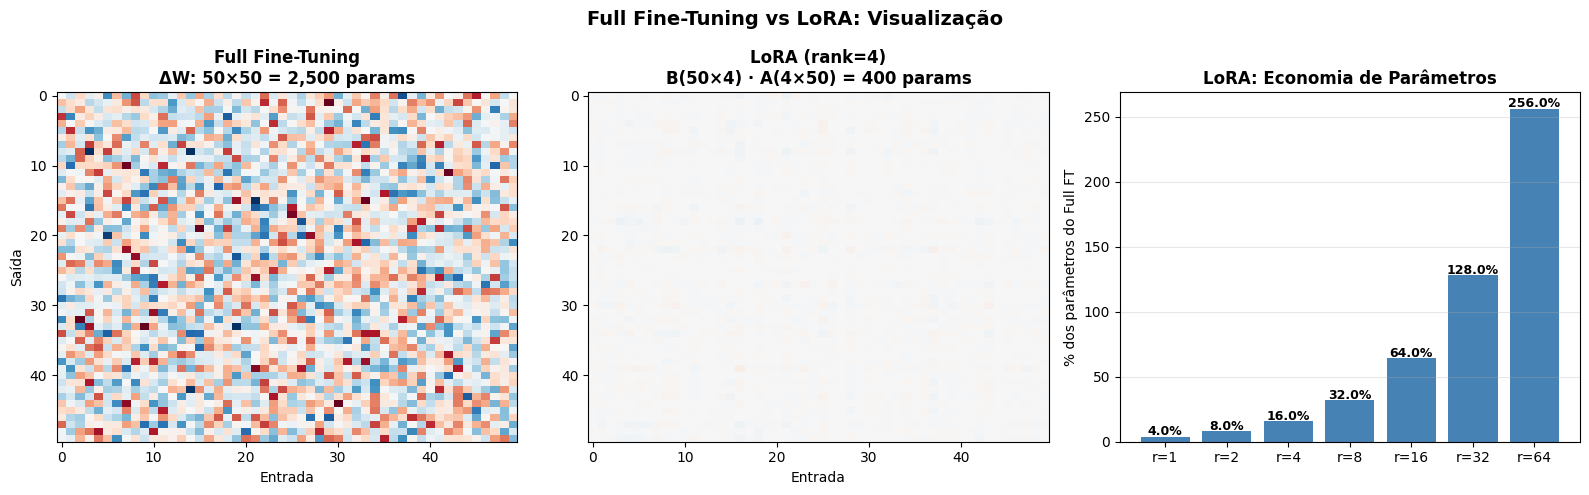

Com rank=16 em um modelo real (d=4096):
Full: 16,777,216 params por camada
LoRA: 131,072 params por camada (0.78%)


In [ ]:
# === Visualizar LoRA: decomposição de baixo rank ===
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Full fine-tuning
ax = axes[0]
d = 50
w_full = np.random.randn(d, d) * 0.02
ax.imshow(w_full, cmap='RdBu', vmin=-0.06, vmax=0.06, aspect='auto')
ax.set_title(f'Full Fine-Tuning\nΔW: {d}×{d} = {d*d:,} params', fontweight='bold', fontsize=12)
ax.set_xlabel('Entrada')
ax.set_ylabel('Saída')

# LoRA
ax = axes[1]
r = 4  # rank
B = np.random.randn(d, r) * 0.02
A = np.random.randn(r, d) * 0.02
delta_w = B @ A

# Mostrar B e A lado a lado
ax.imshow(delta_w, cmap='RdBu', vmin=-0.06, vmax=0.06, aspect='auto')
ax.set_title(f'LoRA (rank={r})\nB({d}×{r}) · A({r}×{d}) = {d*r + r*d:,} params',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Entrada')

# Comparação de parâmetros
ax = axes[2]
ranks = [1, 2, 4, 8, 16, 32, 64]
full_params = d * d
lora_params = [2 * d * r for r in ranks]
ratios = [l / full_params * 100 for l in lora_params]

ax.bar(range(len(ranks)), ratios, color='steelblue')
ax.set_xticks(range(len(ranks)))
ax.set_xticklabels([f'r={r}' for r in ranks])
ax.set_ylabel('% dos parâmetros do Full FT')
ax.set_title('LoRA: Economia de Parâmetros', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
for i, (r_val, ratio) in enumerate(zip(ranks, ratios)):
    ax.text(i, ratio + 1, f'{ratio:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Full Fine-Tuning vs LoRA: Visualização', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Com rank=16 em um modelo real (d=4096):')
print(f'Full: {4096*4096:,} params por camada')
print(f'LoRA: {2*4096*16:,} params por camada ({2*4096*16/(4096*4096)*100:.2f}%)')

---
## 4. Preparação de Dados

### Formatos de dados para fine-tuning

O formato depende do **tipo de fine-tuning**:

| Tipo | Formato | Exemplo |
|------|---------|----------|
| **Instruction tuning** | `{instruction, input, output}` | "Traduza: hello → olá" |
| **Chat fine-tuning** | `{messages: [{role, content}]}` | Conversa multi-turno |
| **Completion** | `{text}` | Texto contínuo para continued pretraining |

### Chat Template

Cada modelo tem seu **template de chat** específico. É crucial usar o template correto!

```
Qwen2.5:
<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
Pergunta aqui<|im_end|>
<|im_start|>assistant
Resposta aqui<|im_end|>
```

In [ ]:
# === Criar dataset de treinamento ===
# Vamos criar um dataset sintético de alta qualidade sobre Python

TRAINING_DATA = [
    {
        "messages": [
            {"role": "system", "content": "Você é um professor de Python paciente e didático. Sempre use exemplos de código e explique passo a passo."},
            {"role": "user", "content": "O que é uma variável em Python?"},
            {"role": "assistant", "content": "Uma variável é como uma caixinha com nome onde você guarda um valor. Veja:\n\n```python\nnome = 'Maria'  # variável guardando texto\nidade = 25       # variável guardando número\naltura = 1.65    # variável guardando decimal\n```\n\nPontos importantes:\n- Não precisa declarar o tipo (Python descobre sozinho)\n- O nome deve começar com letra ou _ (nunca número)\n- Python diferencia maiúsculas de minúsculas: `Nome` e `nome` são diferentes\n\nVocê pode mudar o valor a qualquer momento:\n```python\nidade = 25\nprint(idade)  # 25\nidade = 26    # trocou!\nprint(idade)  # 26\n```"}
        ]
    },
    {
        "messages": [
            {"role": "system", "content": "Você é um professor de Python paciente e didático. Sempre use exemplos de código e explique passo a passo."},
            {"role": "user", "content": "Explique list comprehension em Python."},
            {"role": "assistant", "content": "List comprehension é um jeito elegante de criar listas em uma única linha. É como escrever um for loop de forma compacta.\n\n**Sintaxe básica:**\n```python\n[expressão for item in iterável]\n```\n\n**Exemplo 1 — Quadrados:**\n```python\n# Jeito tradicional\nquadrados = []\nfor x in range(5):\n    quadrados.append(x ** 2)\n\n# Com list comprehension\nquadrados = [x ** 2 for x in range(5)]\nprint(quadrados)  # [0, 1, 4, 9, 16]\n```\n\n**Exemplo 2 — Com filtro:**\n```python\n# Só os pares\npares = [x for x in range(10) if x % 2 == 0]\nprint(pares)  # [0, 2, 4, 6, 8]\n```\n\n**Quando usar:** para transformações simples. Se ficar complicado, use um for normal — legibilidade importa mais!"}
        ]
    },
    {
        "messages": [
            {"role": "system", "content": "Você é um professor de Python paciente e didático. Sempre use exemplos de código e explique passo a passo."},
            {"role": "user", "content": "Qual a diferença entre lista e tupla?"},
            {"role": "assistant", "content": "A diferença principal é que **listas são mutáveis** e **tuplas são imutáveis**.\n\n```python\n# Lista — pode mudar depois de criada\nfrutas = ['maçã', 'banana', 'uva']\nfrutas[0] = 'morango'  # ✅ OK!\nfrutas.append('kiwi')   # ✅ OK!\n\n# Tupla — NÃO pode mudar\ncoordenadas = (10, 20)\ncoordenadas[0] = 30  # ❌ TypeError!\n```\n\n**Quando usar cada:**\n- **Lista** → quando os dados vão mudar (carrinho de compras, lista de tarefas)\n- **Tupla** → quando os dados são fixos (coordenadas, cores RGB, retorno de função)\n\n**Vantagem da tupla:** é mais rápida e pode ser usada como chave de dicionário.\n\n```python\n# Tupla como chave de dict\nlocais = {(23.5, -46.6): 'São Paulo'}\n```"}
        ]
    },
    {
        "messages": [
            {"role": "system", "content": "Você é um professor de Python paciente e didático. Sempre use exemplos de código e explique passo a passo."},
            {"role": "user", "content": "Como funciona try/except?"},
            {"role": "assistant", "content": "O `try/except` serve para tratar erros sem que o programa quebre. Pense assim: 'tente fazer isso, mas se der erro, faça aquilo'.\n\n**Estrutura básica:**\n```python\ntry:\n    # código que pode dar erro\n    resultado = 10 / 0\nexcept ZeroDivisionError:\n    # o que fazer se der erro\n    print('Não pode dividir por zero!')\n```\n\n**Exemplo prático — input do usuário:**\n```python\ntry:\n    idade = int(input('Sua idade: '))\n    print(f'Daqui 10 anos: {idade + 10}')\nexcept ValueError:\n    print('Digite um número válido!')\n```\n\n**Com múltiplos erros:**\n```python\ntry:\n    arquivo = open('dados.txt')\n    numero = int(arquivo.readline())\nexcept FileNotFoundError:\n    print('Arquivo não encontrado!')\nexcept ValueError:\n    print('O arquivo não contém um número!')\nfinally:\n    print('Isso sempre executa (com ou sem erro)')\n```\n\n**Dica:** nunca use `except` sozinho (sem especificar o erro) — isso esconde bugs!"}
        ]
    },
    {
        "messages": [
            {"role": "system", "content": "Você é um professor de Python paciente e didático. Sempre use exemplos de código e explique passo a passo."},
            {"role": "user", "content": "O que são decorators?"},
            {"role": "assistant", "content": "Um decorator é uma função que 'envolve' outra função para adicionar comportamento extra, sem modificar o código original.\n\n**Analogia:** é como colocar um papel de presente em volta de um pacote — o pacote continua o mesmo, mas ganha algo por fora.\n\n**Exemplo simples:**\n```python\ndef medir_tempo(funcao):\n    import time\n    def wrapper(*args, **kwargs):\n        inicio = time.time()\n        resultado = funcao(*args, **kwargs)\n        fim = time.time()\n        print(f'{funcao.__name__} levou {fim - inicio:.2f}s')\n        return resultado\n    return wrapper\n\n@medir_tempo\ndef processar_dados():\n    time.sleep(1)  # simula processamento\n    return 'pronto'\n\nprocessar_dados()  # → 'processar_dados levou 1.00s'\n```\n\nO `@medir_tempo` é equivalente a `processar_dados = medir_tempo(processar_dados)`.\n\n**Decorators comuns no Python:**\n- `@property` — transforma método em atributo\n- `@staticmethod` — método que não precisa de self\n- `@classmethod` — método de classe\n- `@functools.lru_cache` — memoização automática"}
        ]
    },
    {
        "messages": [
            {"role": "system", "content": "Você é um professor de Python paciente e didático. Sempre use exemplos de código e explique passo a passo."},
            {"role": "user", "content": "O que são generators em Python?"},
            {"role": "assistant", "content": "Generators são funções que produzem valores **um de cada vez**, usando `yield` em vez de `return`. Eles são preguiçosos (lazy) — só calculam o próximo valor quando você pede.\n\n**Por que usar?** Economia de memória! Em vez de criar uma lista gigante, gera um item por vez.\n\n```python\n# Lista — guarda TUDO na memória\ndef quadrados_lista(n):\n    return [x**2 for x in range(n)]\n\n# Generator — gera UM por vez\ndef quadrados_gen(n):\n    for x in range(n):\n        yield x**2\n\n# Uso é idêntico:\nfor q in quadrados_gen(5):\n    print(q)  # 0, 1, 4, 9, 16\n```\n\n**A diferença na memória:**\n```python\nimport sys\nlista = quadrados_lista(1_000_000)\ngen = quadrados_gen(1_000_000)\nprint(sys.getsizeof(lista))  # ~8 MB\nprint(sys.getsizeof(gen))    # ~200 bytes!\n```\n\n**Generator expression (versão compacta):**\n```python\ngen = (x**2 for x in range(1_000_000))  # parênteses, não colchetes!\n```\n\nUse generators quando processar dados grandes ou streams infinitos."}
        ]
    },
    {
        "messages": [
            {"role": "system", "content": "Você é um professor de Python paciente e didático. Sempre use exemplos de código e explique passo a passo."},
            {"role": "user", "content": "Como criar e usar dicionários em Python?"},
            {"role": "assistant", "content": "Dicionários são estruturas que guardam dados em pares **chave: valor**. Pense como um dicionário real: você busca pela palavra (chave) e encontra a definição (valor).\n\n```python\naluno = {\n    'nome': 'Carlos',\n    'idade': 22,\n    'notas': [8.5, 9.0, 7.5]\n}\n\n# Acessar\nprint(aluno['nome'])      # 'Carlos'\nprint(aluno.get('email', 'N/A'))  # 'N/A' (não existe, retorna default)\n\n# Adicionar/Modificar\naluno['email'] = 'carlos@mail.com'\naluno['idade'] = 23\n\n# Iterar\nfor chave, valor in aluno.items():\n    print(f'{chave}: {valor}')\n```\n\n**Dict comprehension:**\n```python\nquadrados = {x: x**2 for x in range(5)}\n# {0: 0, 1: 1, 2: 4, 3: 9, 4: 16}\n```\n\n**Dica prática:** use `defaultdict` para evitar verificar se a chave existe:\n```python\nfrom collections import defaultdict\ncontador = defaultdict(int)\ncontador['a'] += 1  # funciona sem erro!\n```"}
        ]
    },
    {
        "messages": [
            {"role": "system", "content": "Você é um professor de Python paciente e didático. Sempre use exemplos de código e explique passo a passo."},
            {"role": "user", "content": "O que é e como usar f-strings?"},
            {"role": "assistant", "content": "F-strings (formatted string literals) são a forma mais prática de inserir variáveis dentro de textos. Basta colocar `f` antes das aspas e usar `{}` para incluir variáveis.\n\n```python\nnome = 'Ana'\nidade = 30\n\n# Jeito antigo\nprint('Olá, ' + nome + '! Você tem ' + str(idade) + ' anos.')\n\n# Com f-string (muito melhor!)\nprint(f'Olá, {nome}! Você tem {idade} anos.')\n```\n\n**Formatação de números:**\n```python\npreco = 49.999\nprint(f'Preço: R${preco:.2f}')         # R$50.00\nprint(f'Grande: {1_000_000:,}')         # 1,000,000\nprint(f'Porcentagem: {0.856:.1%}')      # 85.6%\n```\n\n**Expressões dentro das chaves:**\n```python\nprint(f'2 + 3 = {2 + 3}')               # 2 + 3 = 5\nprint(f'{nome.upper()=}')               # nome.upper()='ANA' (debug!)\n```\n\nF-strings foram introduzidas no Python 3.6 e são o jeito recomendado de formatar strings."}
        ]
    },
    {
        "messages": [
            {"role": "system", "content": "Você é um professor de Python paciente e didático. Sempre use exemplos de código e explique passo a passo."},
            {"role": "user", "content": "Explique classes e objetos em Python."},
            {"role": "assistant", "content": "Uma **classe** é um molde para criar objetos. Um **objeto** é uma instância dessa classe — algo concreto criado a partir do molde.\n\n**Analogia:** a classe é a planta da casa; o objeto é a casa construída.\n\n```python\nclass Cachorro:\n    def __init__(self, nome, raca):\n        self.nome = nome    # atributo\n        self.raca = raca\n        self.energia = 100\n\n    def latir(self):        # método\n        print(f'{self.nome}: Au au!')\n\n    def brincar(self):\n        self.energia -= 20\n        print(f'{self.nome} brincou! Energia: {self.energia}')\n\n# Criar objetos\nrex = Cachorro('Rex', 'Labrador')\nluna = Cachorro('Luna', 'Poodle')\n\nrex.latir()     # Rex: Au au!\nluna.brincar()  # Luna brincou! Energia: 80\n```\n\n**Conceitos-chave:**\n- `__init__`: método construtor (roda quando cria o objeto)\n- `self`: referência ao próprio objeto\n- **Atributos**: dados do objeto (nome, energia)\n- **Métodos**: funções do objeto (latir, brincar)\n\nCada objeto é independente: `rex.energia` e `luna.energia` são diferentes."}
        ]
    },
    {
        "messages": [
            {"role": "system", "content": "Você é um professor de Python paciente e didático. Sempre use exemplos de código e explique passo a passo."},
            {"role": "user", "content": "Como ler e escrever arquivos em Python?"},
            {"role": "assistant", "content": "Python usa a função `open()` para trabalhar com arquivos. Sempre use `with` para garantir que o arquivo será fechado.\n\n**Escrever em arquivo:**\n```python\n# 'w' = write (cria ou sobrescreve)\nwith open('notas.txt', 'w') as f:\n    f.write('Primeira linha\\n')\n    f.write('Segunda linha\\n')\n\n# 'a' = append (adiciona ao final)\nwith open('notas.txt', 'a') as f:\n    f.write('Terceira linha\\n')\n```\n\n**Ler arquivo:**\n```python\n# Ler tudo de uma vez\nwith open('notas.txt', 'r') as f:\n    conteudo = f.read()\n    print(conteudo)\n\n# Ler linha por linha (melhor para arquivos grandes)\nwith open('notas.txt', 'r') as f:\n    for linha in f:\n        print(linha.strip())\n```\n\n**Trabalhar com JSON:**\n```python\nimport json\n\ndados = {'nome': 'Ana', 'idade': 25}\n\n# Salvar\nwith open('dados.json', 'w') as f:\n    json.dump(dados, f, indent=2)\n\n# Carregar\nwith open('dados.json', 'r') as f:\n    dados_lidos = json.load(f)\n```\n\n**Por que usar `with`?** Ele fecha o arquivo automaticamente, mesmo se der erro no meio do código."}
        ]
    },
]

print(f'Dataset de treinamento: {len(TRAINING_DATA)} exemplos')

Dataset de treinamento: 10 exemplos


In [ ]:
import pandas as pd

conversas_df = pd.read_csv('/content/Teste de conversas pix fraude janeiro.csv')

In [ ]:
import re

def preparar_dados_reais(conversas_df):
    training_data = []
    stats = {
        'total_linhas': len(conversas_df),
        'conversas_validas': 0,
        'conversas_invalidas': 0,
        'turnos_usuario': 0,
        'turnos_assistente': 0
    }

    system_message = {
        "role": "system",
        "content": "Você é um assistente especializado em atendimento PicPay para casos de Pix fraude."
    }

    for idx, row in conversas_df.iterrows():
        raw_conversation_text = str(row['messages'])
        parsed_messages = []

        # Dividir a conversa em turnos
        parts = re.split(r'(Usuário:|Assistente:)', raw_conversation_text)

        # Processar primeira parte (se existir)
        start_idx = 1
        if parts and parts[0].strip():
            if not parts[0].startswith(('Usuário:', 'Assistente:')):
                parsed_messages.append({"role": "user", "content": parts[0].strip()})
                stats['turnos_usuario'] += 1

        # Processar pares (label, conteúdo)
        for i in range(start_idx, len(parts), 2):
            if i >= len(parts):
                break

            label = parts[i].strip()

            if label == "Usuário:":
                role = "user"
                stats['turnos_usuario'] += 1
            elif label == "Assistente:":
                role = "assistant"
                stats['turnos_assistente'] += 1
            else:
                continue

            if (i + 1) < len(parts):
                content = parts[i+1].strip()
                if content and len(content) >= 10:  # Filtro de qualidade
                    parsed_messages.append({"role": role, "content": content})

        # Validar conversa antes de adicionar
        if not parsed_messages:
            print(f"⚠️ Linha {idx}: Nenhum turno válido encontrado")
            stats['conversas_invalidas'] += 1
            continue

        # Verificar se tem pelo menos 1 user e 1 assistant
        roles_presentes = {msg['role'] for msg in parsed_messages}
        if 'user' not in roles_presentes or 'assistant' not in roles_presentes:
            print(f"⚠️ Linha {idx}: Faltam turnos de user ou assistant")
            stats['conversas_invalidas'] += 1
            continue

        # Adicionar conversa válida
        full_conversation = [system_message] + parsed_messages
        training_data.append({"messages": full_conversation})
        stats['conversas_validas'] += 1

    # Exibir estatísticas
    print("\n📊 Estatísticas do Processamento:")
    print(f"  Total de linhas: {stats['total_linhas']}")
    print(f"  Conversas válidas: {stats['conversas_validas']}")
    print(f"  Conversas inválidas: {stats['conversas_invalidas']}")
    print(f"  Turnos de usuário: {stats['turnos_usuario']}")
    print(f"  Turnos de assistente: {stats['turnos_assistente']}")
    print(f"  Média de turnos por conversa: {(stats['turnos_usuario'] + stats['turnos_assistente']) / max(stats['conversas_validas'], 1):.1f}")

    return training_data

In [ ]:
# Inspecionar a coluna 'messages' para entender o formato
print("Inspecionando a coluna 'messages' em conversas_df:")
for i in range(min(5, len(conversas_df))):
    message_content = conversas_df.loc[i, 'messages']
    print(f"\nLinha {i}:")
    print(f"  Tipo: {type(message_content)}")
    print(f"  Conteúdo: {message_content[:500]}..." if isinstance(message_content, str) and len(message_content) > 500 else f"  Conteúdo: {message_content}")

Inspecionando a coluna 'messages' em conversas_df:

Linha 0:
  Tipo: <class 'str'>
  Conteúdo: Usuário: Ver mais 
Assistente: Qual Pix você gostaria de contestar?

4. Pix no valor de *R$25,00* para o recebedor: *VANDERLEI PETRONIO DE OLIVEIRA*. (05/01/2026 às 10:50)
5. Pix no valor de *R$20,00* para o recebedor: *Aneliza Laura Mota*. (29/12/2025 às 17:30)
6. Pix no valor de *R$20,00* para o recebedor: *Aneliza Laura Mota*. (24/12/2025 às 19:16)

Responda alguma informação do pix que deseja contestar para selecionar.

Usuário: 2 
Assistente: Qual Pix você gostaria de contestar?

1. Pix no ...

Linha 1:
  Tipo: <class 'str'>
  Conteúdo: Usuário: levei um golpe de 75 reais no utimo pix como posso estorna 
Assistente: Entendi! Você quer contestar o Pix de *R$ 75,00* que foi enviado para *GM TECNOLOGIA & NEGOCIOS LTDA* no dia 31/01/2026 às 17:54. O motivo da contestação é *Golpe ou Fraude*.

Para finalizar o processo, é só tocar no botão 'Concluir contestação' e seguir as orientações na tel

In [ ]:
def validar_dataset(data):
    """Validação completa com estatísticas detalhadas"""
    issues = []
    stats = {
        'total_exemplos': len(data),
        'total_mensagens': 0,
        'tamanho_medio_user': [],
        'tamanho_medio_assistant': [],
        'conversas_curtas': 0,  # < 3 turnos
        'conversas_medias': 0,  # 3-6 turnos
        'conversas_longas': 0   # > 6 turnos
    }

    for i, item in enumerate(data):
        # Verificar estrutura
        if 'messages' not in item:
            issues.append(f"Exemplo {i}: falta campo 'messages'")
            continue

        messages = item['messages']
        stats['total_mensagens'] += len(messages)

        # Classificar tamanho da conversa
        num_turnos = len([m for m in messages if m['role'] in ['user', 'assistant']])
        if num_turnos < 3:
            stats['conversas_curtas'] += 1
        elif num_turnos <= 6:
            stats['conversas_medias'] += 1
        else:
            stats['conversas_longas'] += 1

        # Verificar roles
        roles = [msg['role'] for msg in messages]
        if 'user' not in roles or 'assistant' not in roles:
            issues.append(f"Exemplo {i}: falta role 'user' ou 'assistant'")

        # Coletar estatísticas de tamanho
        for msg in messages:
            if msg['role'] == 'user':
                stats['tamanho_medio_user'].append(len(msg['content']))
            elif msg['role'] == 'assistant':
                stats['tamanho_medio_assistant'].append(len(msg['content']))

            # Verificar tamanho mínimo
            if len(msg['content']) < 10:
                issues.append(f"Exemplo {i}: conteúdo muito curto ({len(msg['content'])} chars)")

    # Exibir resultados
    print("\n📊 Análise de Qualidade do Dataset:")
    print(f"  Total de exemplos: {stats['total_exemplos']}")
    print(f"  Total de mensagens: {stats['total_mensagens']}")
    print(f"  Média de mensagens/exemplo: {stats['total_mensagens'] / max(stats['total_exemplos'], 1):.1f}")

    if stats['tamanho_medio_user']:
        print(f"\n  📝 Mensagens do Usuário:")
        print(f"    Tamanho médio: {sum(stats['tamanho_medio_user']) / len(stats['tamanho_medio_user']):.0f} caracteres")
        print(f"    Tamanho mínimo: {min(stats['tamanho_medio_user'])} caracteres")
        print(f"    Tamanho máximo: {max(stats['tamanho_medio_user'])} caracteres")

    if stats['tamanho_medio_assistant']:
        print(f"\n  🤖 Mensagens do Assistente:")
        print(f"    Tamanho médio: {sum(stats['tamanho_medio_assistant']) / len(stats['tamanho_medio_assistant']):.0f} caracteres")
        print(f"    Tamanho mínimo: {min(stats['tamanho_medio_assistant'])} caracteres")
        print(f"    Tamanho máximo: {max(stats['tamanho_medio_assistant'])} caracteres")

    print(f"\n  📏 Distribuição de Conversas:")
    print(f"    Curtas (< 3 turnos): {stats['conversas_curtas']}")
    print(f"    Médias (3-6 turnos): {stats['conversas_medias']}")
    print(f"    Longas (> 6 turnos): {stats['conversas_longas']}")

    if issues:
        print(f"\n⚠️ {len(issues)} problemas encontrados:")
        for issue in issues[:10]:
            print(f"  - {issue}")
        if len(issues) > 10:
            print(f"  ... e mais {len(issues) - 10} problemas")
    else:
        print("\n✅ Dataset válido!")

    return len(issues) == 0

real_training_data = preparar_dados_reais(conversas_df)
print(f'Total de exemplos de treinamento reais gerados: {len(real_training_data)}')

# Exibir o primeiro exemplo para verificar o formato
if real_training_data:
    print('\nPrimeiro exemplo gerado:')
    pprint(real_training_data[0])

validar_dataset(real_training_data)


⚠️ Linha 0: Faltam turnos de user ou assistant
⚠️ Linha 7: Faltam turnos de user ou assistant
⚠️ Linha 11: Faltam turnos de user ou assistant
⚠️ Linha 12: Faltam turnos de user ou assistant
⚠️ Linha 17: Faltam turnos de user ou assistant
⚠️ Linha 23: Faltam turnos de user ou assistant
⚠️ Linha 24: Faltam turnos de user ou assistant
⚠️ Linha 34: Faltam turnos de user ou assistant
⚠️ Linha 36: Faltam turnos de user ou assistant
⚠️ Linha 38: Faltam turnos de user ou assistant
⚠️ Linha 39: Faltam turnos de user ou assistant
⚠️ Linha 44: Faltam turnos de user ou assistant
⚠️ Linha 47: Faltam turnos de user ou assistant
⚠️ Linha 54: Faltam turnos de user ou assistant
⚠️ Linha 64: Faltam turnos de user ou assistant
⚠️ Linha 66: Faltam turnos de user ou assistant
⚠️ Linha 67: Faltam turnos de user ou assistant
⚠️ Linha 73: Faltam turnos de user ou assistant
⚠️ Linha 74: Faltam turnos de user ou assistant
⚠️ Linha 76: Faltam turnos de user ou assistant
⚠️ Linha 78: Faltam turnos de user ou assi

True

In [ ]:
from datasets import Dataset
import numpy as np
import os

# ============================================
# 1. CRIAR DATASET HUGGINGFACE
# ============================================

print("📦 Criando dataset HuggingFace...")
train_dataset = Dataset.from_list(real_training_data)

print(f"✅ Dataset criado com {len(train_dataset)} exemplos")
print(f"   Colunas: {train_dataset.column_names}")

# ============================================
# 2. FUNÇÃO DE FORMATAÇÃO E TOKENIZAÇÃO
# ============================================

def format_chat_and_tokenize(example):
    """
    Aplica o chat template do tokenizer e tokeniza o texto.

    Args:
        example: Dict com chave 'messages' contendo lista de mensagens

    Returns:
        Dict com 'input_ids', 'attention_mask' e 'labels'
    """
    try:
        # Aplicar chat template
        text = tokenizer.apply_chat_template(
            example['messages'],
            tokenize=False,
            add_generation_prompt=False
        )

        # Tokenizar
        tokenized = tokenizer(
            text,
            truncation=True,
            max_length=1024,
            padding='max_length',  # Adicionar padding explícito aqui
        )

        # Para fine-tuning, labels = input_ids
        return {
            'input_ids': tokenized['input_ids'],
            'attention_mask': tokenized['attention_mask'],
            'labels': tokenized['input_ids'].copy()  # Labels para calcular loss
        }
    except Exception as e:
        print(f"⚠️ Erro ao processar exemplo: {e}")
        # Retornar exemplo vazio para não quebrar o processamento
        return {
            'input_ids': [],
            'attention_mask': [],
            'labels': []
        }

# ============================================
# 3. TOKENIZAR DATASET
# ============================================

print("\n🔄 Tokenizando dataset...")
print(f"   Usando {os.cpu_count()} CPUs")

train_dataset_tokenized = train_dataset.map(
    format_chat_and_tokenize,
    batched=False,  # Processar um por vez para melhor controle de erros
    num_proc=min(4, os.cpu_count()),  # Limitar para evitar overhead
    desc="Tokenizando exemplos"
)

# ============================================
# 4. FILTRAR EXEMPLOS VAZIOS
# ============================================

print("\n🧹 Filtrando exemplos inválidos...")
original_size = len(train_dataset_tokenized)

train_dataset_tokenized = train_dataset_tokenized.filter(
    lambda x: len(x['input_ids']) > 0,
    desc="Filtrando exemplos vazios"
)

filtered_count = original_size - len(train_dataset_tokenized)
if filtered_count > 0:
    print(f"⚠️ {filtered_count} exemplos removidos (vazios ou com erro)")

# ============================================
# 5. REMOVER COLUNA 'MESSAGES'
# ============================================

train_dataset_tokenized = train_dataset_tokenized.remove_columns(['messages'])

print(f"\n✅ Colunas finais: {train_dataset_tokenized.column_names}")

# ============================================
# 6. ANÁLISE DETALHADA DO DATASET
# ============================================

print("\n📊 Análise do Dataset Tokenizado:")
print(f"   Total de exemplos: {len(train_dataset_tokenized)}")

# Estatísticas de tokens
token_counts = [len(ex['input_ids']) for ex in train_dataset_tokenized]

print(f"\n📏 Estatísticas de Tokens:")
print(f"   Mínimo: {min(token_counts)} tokens")
print(f"   Máximo: {max(token_counts)} tokens")
print(f"   Média: {np.mean(token_counts):.1f} tokens")
print(f"   Mediana: {np.median(token_counts):.1f} tokens")
print(f"   Desvio padrão: {np.std(token_counts):.1f} tokens")

# Distribuição por faixas
print(f"\n📊 Distribuição por Faixas:")
faixas = [
    (0, 128, "Muito curto"),
    (128, 256, "Curto"),
    (256, 512, "Médio"),
    (512, 768, "Longo"),
    (768, 1024, "Muito longo"),
    (1024, float('inf'), "Truncado")
]

for min_tok, max_tok, label in faixas:
    count = sum(1 for t in token_counts if min_tok <= t < max_tok)
    percent = (count / len(token_counts)) * 100
    print(f"   {label:15} ({min_tok:4}-{max_tok if max_tok != float('inf') else '∞':4}): {count:4} ({percent:5.1f}%)者にしました。）")

# Verificar truncamento
truncated = sum(1 for t in token_counts if t >= 1024)
if truncated > 0:
    print(f"\n⚠️ {truncated} exemplos foram truncados (>= 1024 tokens)")
    print(f"   Considere aumentar max_length ou dividir conversas longas")

# ============================================
# 7. VISUALIZAR EXEMPLOS
# ============================================

print("\n📄 Exemplos do Dataset Tokenizado:\n")

# Exemplo 1: Mais curto
idx_shortest = token_counts.index(min(token_counts))
print(f"🔹 Exemplo MAIS CURTO (índice {idx_shortest}, {token_counts[idx_shortest]} tokens):")
print("-" * 80)
decoded = tokenizer.decode(train_dataset_tokenized[idx_shortest]['input_ids'])
print(decoded[:500] + ("..." if len(decoded) > 500 else ""))
print()

# Exemplo 2: Médio
idx_median = sorted(range(len(token_counts)), key=lambda i: abs(token_counts[i] - np.median(token_counts)))[0]
print(f"🔹 Exemplo MEDIANO (índice {idx_median}, {token_counts[idx_median]} tokens):")
print("-" * 80)
decoded = tokenizer.decode(train_dataset_tokenized[idx_median]['input_ids'])
print(decoded[:500] + ("..." if len(decoded) > 500 else ""))
print()

# Exemplo 3: Mais longo
idx_longest = token_counts.index(max(token_counts))
print(f"🔹 Exemplo MAIS LONGO (índice {idx_longest}, {token_counts[idx_longest]} tokens):")
print("-" * 80)
decoded = tokenizer.decode(train_dataset_tokenized[idx_longest]['input_ids'])
print(decoded[:500] + ("..." if len(decoded) > 500 else ""))
print()

# ============================================
# 8. VALIDAÇÕES FINAIS
# ============================================

print("\n🔍 Validações Finais:")

# Verificar se há exemplos com tokens especiais corretos
sample_decoded = tokenizer.decode(train_dataset_tokenized[0]['input_ids'])

checks = {
    "Tem tokens de sistema": any(tok in sample_decoded for tok in ['<|im_start|>', '<s>', '[INST]']),
    "Tem tokens de fim": any(tok in sample_decoded for tok in ['<|im_end|>', '</s>', '[/INST]']),
    "Labels presentes": 'labels' in train_dataset_tokenized.column_names,
    "Attention mask presente": 'attention_mask' in train_dataset_tokenized.column_names,
}

for check, passed in checks.items():
    status = "✅" if passed else "❌"
    print(f"   {status} {check}")

# Verificar consistência de tamanhos
inconsistent = sum(
    1 for ex in train_dataset_tokenized
    if len(ex['input_ids']) != len(ex['attention_mask']) or
       len(ex['input_ids']) != len(ex['labels'])
)

if inconsistent > 0:
    print(f"\n❌ {inconsistent} exemplos com tamanhos inconsistentes entre input_ids, attention_mask e labels")
else:
    print(f"\n✅ Todos os exemplos têm tamanhos consistentes")

print("\n" + "="*80)
print("✅ Dataset pronto para treinamento!")
print("="*80)


📦 Criando dataset HuggingFace...
✅ Dataset criado com 718 exemplos
   Colunas: ['messages']

🔄 Tokenizando dataset...
   Usando 2 CPUs


Tokenizando exemplos (num_proc=2):   0%|          | 0/718 [00:00<?, ? examples/s]


🧹 Filtrando exemplos inválidos...


Filtrando exemplos vazios:   0%|          | 0/718 [00:00<?, ? examples/s]


✅ Colunas finais: ['input_ids', 'attention_mask', 'labels']

📊 Análise do Dataset Tokenizado:
   Total de exemplos: 718

📏 Estatísticas de Tokens:
   Mínimo: 1024 tokens
   Máximo: 1024 tokens
   Média: 1024.0 tokens
   Mediana: 1024.0 tokens
   Desvio padrão: 0.0 tokens

📊 Distribuição por Faixas:
   Muito curto     (   0- 128):    0 (  0.0%)者にしました。）
   Curto           ( 128- 256):    0 (  0.0%)者にしました。）
   Médio           ( 256- 512):    0 (  0.0%)者にしました。）
   Longo           ( 512- 768):    0 (  0.0%)者にしました。）
   Muito longo     ( 768-1024):    0 (  0.0%)者にしました。）
   Truncado        (1024-∞   ):  718 (100.0%)者にしました。）

⚠️ 718 exemplos foram truncados (>= 1024 tokens)
   Considere aumentar max_length ou dividir conversas longas

📄 Exemplos do Dataset Tokenizado:

🔹 Exemplo MAIS CURTO (índice 0, 1024 tokens):
--------------------------------------------------------------------------------
<|im_start|>system
Você é um assistente especializado em atendimento PicPay para casos de Pix fraude.

---
## 5. Full Fine-Tuning

Vamos primeiro treinar com **todos os parâmetros** como baseline de comparação.

In [ ]:
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling
import gc

def compute_vram():
    """Retorna VRAM usada em GB."""
    return torch.cuda.memory_allocated() / 1e9

# Limpar memória
# del model_base # Removed as model_base may not be defined, causing NameError
gc.collect()
torch.cuda.empty_cache()

# Carregar modelo fresco para full fine-tuning
print('Carregando modelo para Full Fine-Tuning...')
model_full = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float32,
    device_map='auto',
)

vram_model = compute_vram()
n_trainable_full = sum(p.numel() for p in model_full.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model_full.parameters())

print(f'   VRAM após carregar modelo: {vram_model:.2f} GB')
print(f'   Parâmetros treináveis: {n_trainable_full:,} ({n_trainable_full/n_total*100:.1f}%)')

Carregando modelo para Full Fine-Tuning...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

   VRAM após carregar modelo: 3.97 GB
   Parâmetros treináveis: 494,032,768 (100.0%)


In [ ]:
# Treinar (poucas steps para demo — full FT é caro)
output_dir_full = './results_full'

model_full.config.use_cache = False

training_args_full = TrainingArguments(
    output_dir=output_dir_full,
    num_train_epochs=3,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-5,
    lr_scheduler_type='cosine',
    warmup_steps=2,
    weight_decay=0.01,
    fp16=False,
    logging_steps=1,
    save_strategy='no',
    report_to='none',
    max_grad_norm=1.0,
    gradient_checkpointing=True,
)

trainer_full = Trainer(
    model=model_full,
    args=training_args_full,
    train_dataset=train_dataset_tokenized,
    data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
    processing_class=tokenizer,
)

print('Treinando Full Fine-Tuning...')
t0 = time.time()
result_full = trainer_full.train()
time_full = time.time() - t0
vram_peak_full = torch.cuda.max_memory_allocated() / 1e9

print(f'\nFull FT concluído em {time_full:.0f}s')
print(f'Loss final: {result_full.training_loss:.4f}')
print(f'VRAM pico: {vram_peak_full:.2f} GB')

Treinando Full Fine-Tuning...


Step,Training Loss
1,2.107747
2,2.019107
3,1.344835
4,1.360328
5,0.753938
6,0.855341
7,0.939061
8,0.581094
9,0.710280
10,0.536336


KeyboardInterrupt: 

In [ ]:
# Testar Full FT
print('Respostas do Full Fine-Tuning:\n')

model_full.config.use_cache = True
model_full.eval()

full_responses = {}
for prompt in TEST_PROMPTS[:3]:
    response = generate_response(model_full, tokenizer, prompt)
    full_responses[prompt] = response
    print(f'❓ {prompt}')
    print(f'💬 {response[:300]}...' if len(response) > 300 else f'💬 {response}')
    print(f'{"─"*60}\n')

# Limpar
del model_full, trainer_full
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

Respostas do Full Fine-Tuning:

❓ Explique list comprehension em Python como se eu fosse iniciante.
💬 Lista comprehensão é um conceito bastante simples e básico de Python que permite criar listas sem usar loops. Aqui está uma forma básica:

```python
# Lista vazia
numbers = []

# Compreende todos os números de 1 a 10 (inclusive)
squares = {x: x ** 2 for x in range(10)}
print(squares)  # {'1': '1', '...
────────────────────────────────────────────────────────────

❓ Qual a diferença entre uma lista e uma tupla em Python?
💬 **Listas:** são grupos de dados que podem ser acessadas de forma individual (sem usar índices), mas não são ordenadas.

```python
frutas = ['maçã', 'banana', 'kiwi']
print(frutas[0])  # Output: maçã
```

**Tuplas:** são grupos de dados que permanecem inalteráveis e não são acessíveis de forma indivi...
────────────────────────────────────────────────────────────

❓ Como tratar erros com try/except em Python? Dê um exemplo.
💬 O `try/except` é usado para tentar fazer al

---
## 6. LoRA Fine-Tuning

Agora vamos treinar com **LoRA** — apenas uma fração dos parâmetros.

### Parâmetros do LoRA:
- **r (rank):** dimensão das matrizes de adaptação (8-64 típico)
- **alpha:** fator de escala ($\alpha / r$). Regra: $\alpha = 2 \times r$
- **target_modules:** quais camadas recebem adaptadores (q_proj, v_proj, etc.)
- **dropout:** regularização nos adaptadores

In [ ]:
from peft import LoraConfig, get_peft_model, TaskType

# Carregar modelo fresco
print('Carregando modelo para LoRA...')
model_lora_base = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map='auto',
)

# Configurar LoRA
lora_config = LoraConfig(
    r=16,                          # rank dos adaptadores
    lora_alpha=32,                 # scaling factor (tipicamente 2*r)
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj',   # atenção
                    'gate_proj', 'up_proj', 'down_proj'],       # MLP
    lora_dropout=0.05,
    bias='none',
    task_type=TaskType.CAUSAL_LM,
)

# Aplicar LoRA
model_lora = get_peft_model(model_lora_base, lora_config)

# Estatísticas
trainable_params = sum(p.numel() for p in model_lora.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_lora.parameters())
vram_lora = compute_vram()

print(f'\nLoRA Stats:')
print(f'   Total params:     {total_params:>12,}')
print(f'   Trainable params: {trainable_params:>12,} ({trainable_params/total_params*100:.2f}%)')
print(f'   Frozen params:    {total_params - trainable_params:>12,}')
print(f'   VRAM:             {vram_lora:.2f} GB')
print(f'\n   Economia: {(1 - trainable_params/n_trainable_full)*100:.1f}% menos parâmetros treináveis!')

# Mostrar quais camadas foram modificadas
model_lora.print_trainable_parameters()

Carregando modelo para LoRA...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


LoRA Stats:
   Total params:      502,830,976
   Trainable params:    8,798,208 (1.75%)
   Frozen params:     494,032,768
   VRAM:             1.04 GB

   Economia: 98.2% menos parâmetros treináveis!
trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497


In [ ]:
# Treinar LoRA
output_dir_lora = './results_lora'

training_args_lora = TrainingArguments(
    output_dir=output_dir_lora,
    num_train_epochs=5,  # mais epochs pois menos parâmetros
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,  # LR maior para LoRA (recomendado)
    lr_scheduler_type='cosine',
    warmup_steps=2,
    weight_decay=0.01,
    fp16=False,
    logging_steps=1,
    save_strategy='no',
    report_to='none',
    max_grad_norm=1.0,
)

trainer_lora = Trainer(
    model=model_lora,
    args=training_args_lora,
    train_dataset=train_dataset_tokenized,
    data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
    processing_class=tokenizer,
)

print('Treinando LoRA...')
t0 = time.time()
result_lora = trainer_lora.train()
time_lora = time.time() - t0
vram_peak_lora = torch.cuda.max_memory_allocated() / 1e9

print(f'\nLoRA concluído em {time_lora:.0f}s')
print(f'   Loss final: {result_lora.training_loss:.4f}')
print(f'   VRAM pico: {vram_peak_lora:.2f} GB')

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Treinando LoRA...


Step,Training Loss
1,1.781688
2,1.895587
3,1.602133
4,1.516669
5,1.202411
6,1.420999
7,1.047101
8,1.025027
9,0.932569
10,0.961466



LoRA concluído em 12s
   Loss final: 1.3386
   VRAM pico: 4.25 GB


In [ ]:
# Testar LoRA
print('Respostas do LoRA Fine-Tuning:\n')

model_lora.config.use_cache = True
model_lora.eval()

lora_responses = {}
for prompt in TEST_PROMPTS[:3]:
    response = generate_response(model_lora, tokenizer, prompt)
    lora_responses[prompt] = response
    print(f'❓ {prompt}')
    print(f'💬 {response[:300]}...' if len(response) > 300 else f'💬 {response}')
    print(f'{"─"*60}\n')

# Salvar adaptador LoRA
model_lora.save_pretrained('./lora_adapter')
adapter_size = sum(os.path.getsize(os.path.join('./lora_adapter', f))
                   for f in os.listdir('./lora_adapter') if f.endswith('.safetensors')) / 1e6
print(f'Adaptador LoRA salvo: {adapter_size:.1f} MB')

del model_lora, model_lora_base, trainer_lora
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

Respostas do LoRA Fine-Tuning:

❓ Explique list comprehension em Python como se eu fosse iniciante.
💬 List comprehension é uma forma de criar lists (arrays) usando expressões que são agrupadas dentro delas. É mais rápido e eficiente do que fazer o mesmo com for ou while.

```python
numbers = [x**2 for x in range(10)]
```

Essa lista `numbers` contém todos os números quadrados de 0 até 9:

```python
...
────────────────────────────────────────────────────────────

❓ Qual a diferença entre uma lista e uma tupla em Python?
💬 Na linguagem de programação Python, uma lista é uma estrutura de dados que pode armazenar qualquer tipo de dado (como números, strings ou listas) em ordem individual. Aqui está uma explicação:

```python
# Listas são mutáveis - podemos adicionar, remover, modificar elementos
frutas = ['maçã', 'banan...
────────────────────────────────────────────────────────────

❓ Como tratar erros com try/except em Python? Dê um exemplo.
💬 Em Python, você pode usar `try/except` para

---
## 7. QLoRA Fine-Tuning

Agora o modelo base é carregado em **4 bits** — o mínimo possível de VRAM.

In [ ]:
from transformers import BitsAndBytesConfig

# Configuração de quantização 4-bit
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',         # Normal Float 4-bit (melhor que FP4 uniforme)
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,     # Quantização dupla (economiza mais)
)

print('Carregando modelo em 4-bit para QLoRA...')
model_qlora_base = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map='auto',
)
model_qlora_base.config.use_cache = False

vram_4bit = compute_vram()
print(f'   VRAM com modelo 4-bit: {vram_4bit:.2f} GB')

# Aplicar LoRA sobre o modelo quantizado
from peft import prepare_model_for_kbit_training

model_qlora_base = prepare_model_for_kbit_training(model_qlora_base)
model_qlora = get_peft_model(model_qlora_base, lora_config)

# FIX: Qwen2.5 usa bf16 nativamente — converter para evitar conflito com GradScaler fp16
for param in model_qlora.parameters():
    if param.data.dtype == torch.bfloat16:
        param.data = param.data.to(torch.float16)
    if param.requires_grad:
        param.data = param.data.to(torch.float32)

trainable_q = sum(p.numel() for p in model_qlora.parameters() if p.requires_grad)
total_q = sum(p.numel() for p in model_qlora.parameters())

print(f'\nQLoRA Stats:')
print(f'   Total params:     {total_q:>12,}')
print(f'   Trainable params: {trainable_q:>12,} ({trainable_q/total_q*100:.2f}%)')
print(f'   VRAM:             {compute_vram():.2f} GB')
model_qlora.print_trainable_parameters()


Carregando modelo em 4-bit para QLoRA...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

   VRAM com modelo 4-bit: 0.48 GB

QLoRA Stats:
   Total params:      323,917,696
   Trainable params:    8,798,208 (2.72%)
   VRAM:             0.79 GB
trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497


In [ ]:
# Treinar QLoRA
output_dir_qlora = './results_qlora'

training_args_qlora = TrainingArguments(
    output_dir=output_dir_qlora,
    num_train_epochs=5,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    lr_scheduler_type='cosine',
    warmup_steps=2,
    weight_decay=0.01,
    fp16=False,
    logging_steps=1,
    save_strategy='no',
    report_to='none',
    max_grad_norm=1.0,
)

trainer_qlora = Trainer(
    model=model_qlora,
    args=training_args_qlora,
    train_dataset=train_dataset_tokenized,
    data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
    processing_class=tokenizer,
)

print('Treinando QLoRA...')
t0 = time.time()
result_qlora = trainer_qlora.train()
time_qlora = time.time() - t0
vram_peak_qlora = torch.cuda.max_memory_allocated() / 1e9

print(f'\nQLoRA concluído em {time_qlora:.0f}s')
print(f'   Loss final: {result_qlora.training_loss:.4f}')
print(f'   VRAM pico: {vram_peak_qlora:.2f} GB')

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Treinando QLoRA...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
1,1.855364
2,1.934108
3,1.667394
4,1.615005
5,1.256603
6,1.480587
7,1.080620
8,1.094674
9,0.981257
10,0.973588



QLoRA concluído em 15s
   Loss final: 1.3939
   VRAM pico: 2.32 GB


In [ ]:
# Testar QLoRA
print('Respostas do QLoRA Fine-Tuning:\n')

model_qlora.config.use_cache = True
model_qlora.eval()

qlora_responses = {}
for prompt in TEST_PROMPTS[:3]:
    response = generate_response(model_qlora, tokenizer, prompt)
    qlora_responses[prompt] = response
    print(f'❓ {prompt}')
    print(f'💬 {response[:300]}...' if len(response) > 300 else f'💬 {response}')
    print(f'{"─"*60}\n')

Respostas do QLoRA Fine-Tuning:

❓ Explique list comprehension em Python como se eu fosse iniciante.
💬 List comprehension é uma forma de criar lists (arrays) usando compreensões de linguagem. Vou explicar como usar ela:

1. **Definindo a função**: Primeiro, você define uma função que gera seus dados. Por exemplo:
   ```python
   def gerar_dados():
       return [1, 2, 3]
   ```

2. **Usando a função*...
────────────────────────────────────────────────────────────

❓ Qual a diferença entre uma lista e uma tupla em Python?
💬 A diferença principal é que as listas são mutáveis (sem necessidade de declarar), enquanto as tuplas são imutáveis.

```python
# Lista (mutable)
my_list = [1, 2, 3]
print(my_list)  # ['1', '2', '3']

# Tupla (immutável)
my_tuple = (4, 5, 6)
print(my_tuple)  # (4, 5, 6)

# Sintaxe do python:
# Uma li...
────────────────────────────────────────────────────────────

❓ Como tratar erros com try/except em Python? Dê um exemplo.
💬 Aqui está uma explicação básica sobre como

---
## 8. Comparação: Full vs LoRA vs QLoRA

COMPARAÇÃO COMPLETA:

                  |       Full Fine-Tuning |            LoRA (r=16) |    QLoRA (r=16, 4-bit)
--------------------------------------------------------------------------------------------
Params Treináveis |            494,032,768 |              8,798,208 |              8,798,208
     % Treináveis |                 100.0% |                  1.78% |                  2.72%
   VRAM Pico (GB) |                   9.57 |                   4.25 |                   2.32
        Tempo (s) |                     14 |                     12 |                     15
       Loss Final |                 1.2577 |                 1.3386 |                 1.3939


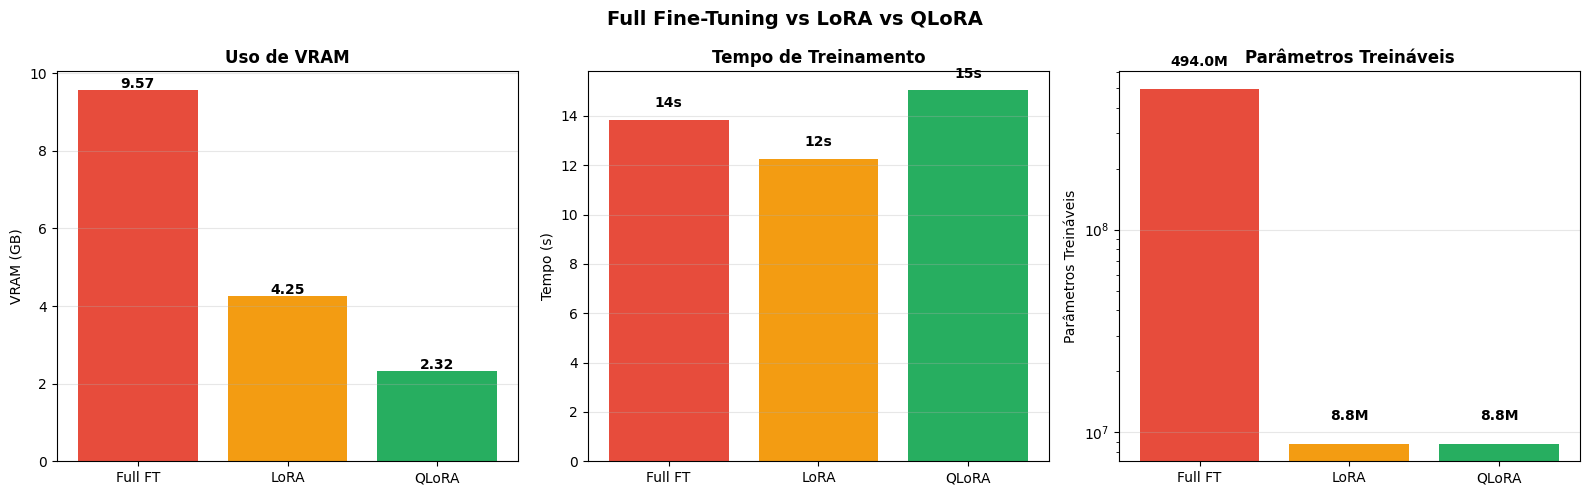

In [ ]:
# === Grande comparação ===
comparison = {
    'Método': ['Full Fine-Tuning', 'LoRA (r=16)', 'QLoRA (r=16, 4-bit)'],
    'Params Treináveis': [f'{n_trainable_full:,}', f'{trainable_params:,}', f'{trainable_q:,}'],
    '% Treináveis': [f'{100:.1f}%', f'{trainable_params/n_total*100:.2f}%', f'{trainable_q/total_q*100:.2f}%'],
    'VRAM Pico (GB)': [f'{vram_peak_full:.2f}', f'{vram_peak_lora:.2f}', f'{vram_peak_qlora:.2f}'],
    'Tempo (s)': [f'{time_full:.0f}', f'{time_lora:.0f}', f'{time_qlora:.0f}'],
    'Loss Final': [f'{result_full.training_loss:.4f}', f'{result_lora.training_loss:.4f}', f'{result_qlora.training_loss:.4f}'],
}

print('COMPARAÇÃO COMPLETA:\n')
# Imprimir como tabela
max_key_len = max(len(k) for k in comparison.keys())
header = f'{"":>{max_key_len}} | ' + ' | '.join(f'{m:>22}' for m in comparison['Método'])
print(header)
print('-' * len(header))
for key in list(comparison.keys())[1:]:
    row = f'{key:>{max_key_len}} | ' + ' | '.join(f'{v:>22}' for v in comparison[key])
    print(row)

# Gráfico comparativo
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
methods = ['Full FT', 'LoRA', 'QLoRA']
colors = ['#e74c3c', '#f39c12', '#27ae60']

# VRAM
vrams = [vram_peak_full, vram_peak_lora, vram_peak_qlora]
axes[0].bar(methods, vrams, color=colors)
axes[0].set_ylabel('VRAM (GB)')
axes[0].set_title('Uso de VRAM', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(vrams):
    axes[0].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

# Tempo
times = [time_full, time_lora, time_qlora]
axes[1].bar(methods, times, color=colors)
axes[1].set_ylabel('Tempo (s)')
axes[1].set_title('Tempo de Treinamento', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(times):
    axes[1].text(i, v + 0.5, f'{v:.0f}s', ha='center', fontweight='bold')

# Parâmetros treináveis (log scale)
params_train = [n_trainable_full, trainable_params, trainable_q]
axes[2].bar(methods, params_train, color=colors)
axes[2].set_ylabel('Parâmetros Treináveis')
axes[2].set_title('Parâmetros Treináveis', fontweight='bold')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(params_train):
    axes[2].text(i, v * 1.3, f'{v/1e6:.1f}M', ha='center', fontweight='bold')

plt.suptitle('Full Fine-Tuning vs LoRA vs QLoRA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Treinamento com SFTTrainer (Hugging Face TRL)

O `SFTTrainer` (Supervised Fine-Tuning Trainer) do TRL simplifica tudo:
- Aplica chat template automaticamente
- Suporte nativo a LoRA/QLoRA
- Packing de sequências (eficiência)
- Logging integrado com W&B

In [ ]:
from trl import SFTTrainer, SFTConfig
from peft import prepare_model_for_kbit_training, get_peft_model
from transformers import BitsAndBytesConfig
import gc
import torch

# Limpar memória de forma segura
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

# 1. Redefinir BNB Config para GARANTIR o float16
bnb_config_sft = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

# 2. Modelo 4-bit fresco
model_sft_base = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config_sft,
    torch_dtype=torch.float16,
    device_map='auto',
)
model_sft_base.config.use_cache = False

# 3. Preparar QLoRA manualmente antes do Trainer
model_sft_base = prepare_model_for_kbit_training(model_sft_base)
model_sft_peft = get_peft_model(model_sft_base, lora_config)

# === FIX DTYPE: Qwen2.5 é nativamente bf16 ===
# O GradScaler do fp16 não suporta gradientes em bf16.
# Solução: converter qualquer parâmetro bf16 residual para fp16,
# e garantir que os treináveis (LoRA) fiquem em float32.
for name, param in model_sft_peft.named_parameters():
    if param.data.dtype == torch.bfloat16:
        param.data = param.data.to(torch.float16)
    if param.requires_grad:
        param.data = param.data.to(torch.float32)

sft_config = SFTConfig(
    output_dir='./results_sft',
    max_length=1024,
    num_train_epochs=5,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    lr_scheduler_type='cosine',
    warmup_steps=2,
    weight_decay=0.01,
    fp16=False,
    bf16=False,
    logging_steps=1,
    save_strategy='no',
    report_to='none',
    packing=False,
    max_grad_norm=1.0,
)

# 4. Passar o modelo JÁ COM LORA para o Trainer
trainer_sft = SFTTrainer(
    model=model_sft_peft,
    args=sft_config,
    train_dataset=train_dataset,
    # peft_config=lora_config,
    processing_class=tokenizer,
)

print('Treinando com SFTTrainer (QLoRA)...')
result_sft = trainer_sft.train()
print(f'\nSFTTrainer concluído! Loss: {result_sft.training_loss:.4f}')

# Testar
print('\nRespostas do SFTTrainer:\n')

trainer_sft.model.config.use_cache = True
trainer_sft.model.eval()

with torch.no_grad():
    for prompt in TEST_PROMPTS[:3]:
        response = generate_response(trainer_sft.model, tokenizer, prompt)
        print(f'❓ {prompt}')
        print(f'💬 {response[:300]}...' if len(response) > 300 else f'💬 {response}')
        print(f'{"─"*60}\n')


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Tokenizing train dataset:   0%|          | 0/10 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/10 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Treinando com SFTTrainer (QLoRA)...


Step,Training Loss
1,1.855283
2,1.933862
3,1.667601
4,1.614769
5,1.257068
6,1.482049
7,1.081196
8,1.096326
9,0.982444
10,0.976715



SFTTrainer concluído! Loss: 1.3947

Respostas do SFTTrainer:

❓ Explique list comprehension em Python como se eu fosse iniciante.
💬 List comprehension é uma forma de criar lists (arrays) rapidamente e efetivamente usando compreensão de lista.

**1. Exemplo 1: Listar números pares de 0 até 20**
```python
# Usando list comprehension para gerar um list com todos os números pares de 0 até 20
pares = [x for x in range(20)]  # x é o i...
────────────────────────────────────────────────────────────

❓ Qual a diferença entre uma lista e uma tupla em Python?
💬 A diferença principal é que as listas são mutáveis (sem necessidade de declarar), enquanto as tuplas são imutáveis.

```python
# Lista (mutable)
my_list = [1, 2, 3]
print(my_list)  # ['1', '2', '3']

# Tupla (immutável)
my_tuple = (4, 5, 6)
print(my_tuple)  # (4, 5, 6)

# Sintaxe do python:
# lista ...
────────────────────────────────────────────────────────────

❓ Como tratar erros com try/except em Python? Dê um exemplo.
💬 Aqui está um

---
## 10. Merge, Export e Deploy

### Opções de deploy:

```
Adaptor LoRA (~10 MB)         → Manter separado se trocar adaptadores
    ↓ merge
Modelo completo (FP16, ~1 GB) → Deploy padrão (vLLM, TGI)
    ↓ quantize
Modelo GGUF (Q4_K_M, ~300 MB) → Deploy local (llama.cpp, Ollama)
```

In [ ]:
# === Merge: fundir adaptador de volta no modelo base ===
print('Fazendo merge do adaptador LoRA no modelo base...\n')

# Salvar adaptador
trainer_sft.model.save_pretrained('./final_adapter')
tokenizer.save_pretrained('./final_adapter')

# Para merge, precisamos carregar o modelo base em FP16 (não quantizado)
del trainer_sft, model_sft_base
gc.collect()
torch.cuda.empty_cache()

from peft import PeftModel

# Carregar base FP16
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map='auto',
)

# Aplicar adaptador
merged_model = PeftModel.from_pretrained(base_model, './final_adapter')

# Merge
merged_model = merged_model.merge_and_unload()

# Salvar modelo completo
merged_model.save_pretrained('./final_merged_model')
tokenizer.save_pretrained('./final_merged_model')

# Tamanhos
adapter_size = sum(os.path.getsize(os.path.join('./final_adapter', f))
                   for f in os.listdir('./final_adapter')
                   if os.path.isfile(os.path.join('./final_adapter', f))) / 1e6
merged_size = sum(os.path.getsize(os.path.join('./final_merged_model', f))
                  for f in os.listdir('./final_merged_model')
                  if os.path.isfile(os.path.join('./final_merged_model', f))) / 1e6

print(f'Artefatos:')
print(f'   Adaptador LoRA:    {adapter_size:.1f} MB')
print(f'   Modelo merged:     {merged_size:.1f} MB')
print(f'   Economia (adapter): {(1 - adapter_size/merged_size)*100:.1f}%')

Fazendo merge do adaptador LoRA no modelo base...



Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Artefatos:
   Adaptador LoRA:    29.1 MB
   Modelo merged:     999.5 MB
   Economia (adapter): 97.1%


In [ ]:
# Testar modelo merged
print('Respostas do modelo MERGED (verificação):\n')

# Carregar do disco (simula deploy)
deployed_model = AutoModelForCausalLM.from_pretrained(
    './final_merged_model',
    torch_dtype=torch.float16,
    device_map='auto',
)
deployed_tokenizer = AutoTokenizer.from_pretrained('./final_merged_model')

for prompt in TEST_PROMPTS[:2]:
    response = generate_response(deployed_model, deployed_tokenizer, prompt)
    print(f'❓ {prompt}')
    print(f'💬 {response[:300]}...' if len(response) > 300 else f'💬 {response}')
    print(f'{"─"*60}\n')

print('Modelo merged funciona corretamente!')

Respostas do modelo MERGED (verificação):



Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

❓ Explique list comprehension em Python como se eu fosse iniciante.
💬 List comprehension é uma forma de gerar listas ou dicionários com apenas uma linha de código. Aqui está um exemplo simples:

```python
# Gerando uma lista de números pares de 1 até 50
numeros_pares = [x for x in range(1, 51) if x % 2 == 0]

print(numeros_pares)
# Output: [2, 4, 6, 8, 10, 12, 14, 16,...
────────────────────────────────────────────────────────────

❓ Qual a diferença entre uma lista e uma tupla em Python?
💬 Em Python, as listas e as tuplas são ambíguas (duas opções sem um valor específico) e não temos métodos específicos para cada uma.

**Listas:**
- **Definição:** É uma estrutura de dados que contém vários elementos.
- **Composição:** `lista = [1, 2, 3]`
- **Acesso individual:** `lista[0]` retorna o p...
────────────────────────────────────────────────────────────

Modelo merged funciona corretamente!


---
## 11. Experimentos: Rank, Alpha, Target Modules

### Experimento: Efeito do Rank (r) no LoRA

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


  Rank r= 4 (2,199,552 params)... 

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
1,1.855902
2,1.838571
3,1.651546
4,1.775021
5,1.527237
6,1.819155


...

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


  Rank r=64 (35,192,832 params)... 

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
1,1.855902
2,1.587543
3,1.325543
4,1.261513
5,0.821947
6,0.933003


loss=1.2976, VRAM=4.63GB


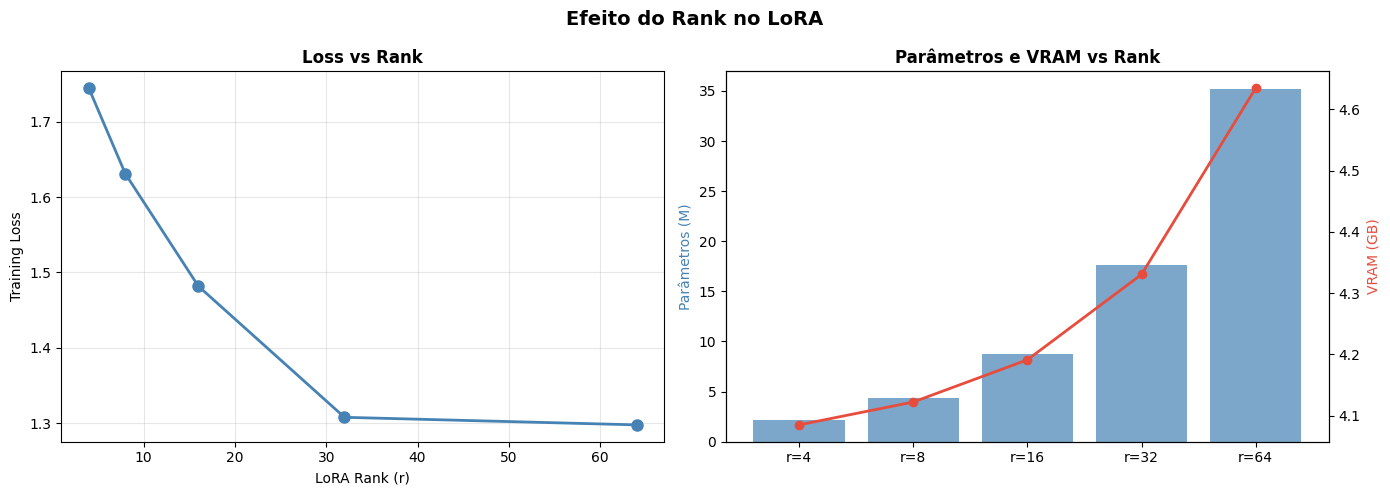


Observação típica:
   - r=4 a r=16: melhora significativa
   - r=16 a r=64: retornos decrescentes
   - r=16 é geralmente o sweet spot para a maioria das tarefas


In [ ]:
# === Comparar diferentes ranks ===
del deployed_model, merged_model, base_model
gc.collect()
torch.cuda.empty_cache()

ranks_to_test = [4, 8, 16, 32, 64]
rank_results = []

for r in ranks_to_test:
    torch.cuda.reset_peak_memory_stats()

    # Modelo fresco
    m = AutoModelForCausalLM.from_pretrained(MODEL_ID, quantization_config=bnb_config, device_map='auto')
    m = prepare_model_for_kbit_training(m)

    cfg = LoraConfig(
        r=r, lora_alpha=r*2,
        target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'],
        lora_dropout=0.05, bias='none', task_type=TaskType.CAUSAL_LM,
    )
    m = get_peft_model(m, cfg)

    # FIX: converter bf16 residual → fp16, treináveis → float32
    for param in m.parameters():
        if param.data.dtype == torch.bfloat16:
            param.data = param.data.to(torch.float16)
        if param.requires_grad:
            param.data = param.data.to(torch.float32)

    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)

    args = TrainingArguments(
        output_dir=f'./rank_test_r{r}', num_train_epochs=3,
        per_device_train_batch_size=2, gradient_accumulation_steps=4,
        learning_rate=2e-4, fp16=True, logging_steps=1,
        save_strategy='no', report_to='none',
    )
    trainer = Trainer(m, args, train_dataset=train_dataset_tokenized,
                      data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
                      processing_class=tokenizer)

    print(f'  Rank r={r:2d} ({trainable:,} params)...', end=' ')
    result = trainer.train()
    vram = torch.cuda.max_memory_allocated() / 1e9

    rank_results.append({
        'rank': r, 'trainable': trainable,
        'loss': result.training_loss, 'vram': vram
    })
    print(f'loss={result.training_loss:.4f}, VRAM={vram:.2f}GB')

    del m, trainer
    gc.collect()
    torch.cuda.empty_cache()

# Visualizar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ranks_plot = [r['rank'] for r in rank_results]
losses_plot = [r['loss'] for r in rank_results]
vrams_plot = [r['vram'] for r in rank_results]
params_plot = [r['trainable']/1e6 for r in rank_results]

ax1.plot(ranks_plot, losses_plot, 'o-', color='steelblue', linewidth=2, markersize=8)
ax1.set_xlabel('LoRA Rank (r)')
ax1.set_ylabel('Training Loss')
ax1.set_title('Loss vs Rank', fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.bar(range(len(ranks_plot)), params_plot, color='steelblue', alpha=0.7)
ax2_twin = ax2.twinx()
ax2_twin.plot(range(len(ranks_plot)), vrams_plot, 'o-', color='#e74c3c', linewidth=2)
ax2.set_xticks(range(len(ranks_plot)))
ax2.set_xticklabels([f'r={r}' for r in ranks_plot])
ax2.set_ylabel('Parâmetros (M)', color='steelblue')
ax2_twin.set_ylabel('VRAM (GB)', color='#e74c3c')
ax2.set_title('Parâmetros e VRAM vs Rank', fontweight='bold')

plt.suptitle('Efeito do Rank no LoRA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nObservação típica:')
print('   - r=4 a r=16: melhora significativa')
print('   - r=16 a r=64: retornos decrescentes')
print('   - r=16 é geralmente o sweet spot para a maioria das tarefas')


---
## 12. Receita de Depuração + Erros Comuns

### Checklist quando o fine-tuning não funciona:

```
1. 📋 DADOS
   □ Chat template correto? (cada modelo tem o seu!)
   □ Dados formatados como o modelo espera?
   □ Exemplos longos demais? (truncamento pode cortar a resposta)
   □ Quantidade suficiente? (mínimo ~100 exemplos de qualidade)
   □ Qualidade boa? (garbage in → garbage out)

2. 📐 HIPERPARÂMETROS
   □ LR: Full FT = 1e-5 a 5e-5, LoRA = 1e-4 a 3e-4
   □ Epochs: 1-3 para datasets grandes, 3-10 para pequenos
   □ Batch size efetivo: batch_size × gradient_accumulation ≥ 8
   □ LoRA rank: comece com r=16, alpha=32

3. 🔧 TÉCNICOS
   □ model.config.use_cache = False (necessário para gradient checkpointing)
   □ pad_token definido? (muitos modelos não têm por padrão)
   □ VRAM suficiente? (OOM = reduzir batch_size ou usar QLoRA)
   □ gradient_checkpointing_enable() se VRAM apertada

4. 🎯 LORA-SPECIFIC
   □ target_modules corretos? (varia por arquitetura)
   □ Merge antes de inferência? (ou usar model.eval())
   □ prepare_model_for_kbit_training() para QLoRA
```

### Erros comuns:

| Erro | Causa provável | Solução |
|------|----------------|----------|
| CUDA OOM | Batch muito grande ou modelo muito grande | Reduzir batch, usar QLoRA, gradient checkpointing |
| Loss não diminui | LR errado ou dados mal formatados | Verificar chat template, ajustar LR |
| Loss = NaN | LR muito alto ou overflow | Reduzir LR, usar bf16 em vez de fp16 |
| Modelo repete texto | Overfitting (poucas amostras) | Mais dados, menos epochs, aumentar dropout |
| Resposta truncada | max_seq_length muito curto | Aumentar max_seq_length no SFTConfig |
| Formato errado na saída | Chat template errado | Verificar tokenizer.apply_chat_template() |

---
## Resumo e Referência Rápida

### Decisões para Fine-Tuning

| Decisão | Recomendação | Por quê |
|---|---|---|
| **Método** | QLoRA (padrão), Full FT (se VRAM sobra) | QLoRA é 4× mais eficiente |
| **Rank** | r=16, alpha=32 | Sweet spot qualidade/custo |
| **Targets** | Todos (q,k,v,o,gate,up,down) | Melhor que só q,v |
| **LR** | 2e-4 (LoRA), 2e-5 (Full FT) | LoRA precisa de LR maior |
| **Epochs** | 3-5 (dataset pequeno), 1-2 (grande) | Evitar overfitting |
| **Batch efetivo** | ≥ 8 (via gradient accumulation) | Estabilidade |
| **Scheduler** | Cosine com warmup_steps | Padrão da indústria |

### Fluxo completo

```
1. Preparar dados (formato chat/instruction)
2. Escolher modelo base (Qwen, Llama, Phi, Gemma)
3. Configurar LoRA/QLoRA
4. Treinar com SFTTrainer
5. Avaliar (perplexidade + geração manual)
6. Merge adaptador → modelo completo
7. (Opcional) Quantizar para GGUF
8. Deploy (vLLM, TGI, Ollama, llama.cpp)
```

### O que aprendemos:

> **LoRA/QLoRA democratizou o fine-tuning.**
> Com uma GPU de 16 GB, é possível adaptar modelos de bilhões de parâmetros
> para tarefas específicas, usando ~1% dos parâmetros originais,
> com qualidade comparável ao full fine-tuning.
> A qualidade dos dados é mais importante que a quantidade de parâmetros.